In [1]:
# Do not forget: $ poetry run jupyter notebook

%matplotlib inline
%reload_ext autoreload
%autoreload 2

import torch
DEVICE = torch.device('cpu')

# NAME = 'ladle_furnace_inference'

# **Inference: NN to estimate scattering**

## **Building scenarios with different detector configurations**

We will begin by defining 4 scenarios with different detector configurations. Each scenario corresponds to a **volume**, consisting of the configured **detectors** and a **passive volume**. 

In [2]:
from tomopt.volume import Volume
from tomopt.benchmarks.ladle_furnace import get_detector

In [3]:
# Panel span [cm]
PanelSpan = 0.7
#PanelSpan = 0.9

# muon hit detection resolution [m]
Resolution = 0.00001 # 0,01 mm (really high resolution)

PanelZ = [1.80, 1.65, 1.50, 0.30, 0.15, 0.00] # Big gap

volume_BigGapHighRes = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_BigGapHighRes

# muon hit detection resolution [m]
Resolution = 0.001 # 1 mm (common muography detector)

volume_BigGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_BigGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.25, 0.20] # Small gap

volume_SmallGap = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_SmallGap

PanelZ = [1.60, 1.55, 1.50, 0.30, 0.15, 0.00] # Not centred

volume_NotCentred = Volume(get_detector(device=DEVICE, span=PanelSpan, res=Resolution, panelZpositions=PanelZ), budget=6)
volume_NotCentred


Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

In [4]:
volume_BigGap.layers[0]

PanelDetectorLayer(
  (panels): ModuleList(
    (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
    (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
  )
)

We can visualise the layout of this in 3D.

#### a) Big gap detection panels

In [5]:
# To do: Specify panel span in .draw method

<IPython.core.display.Javascript object>


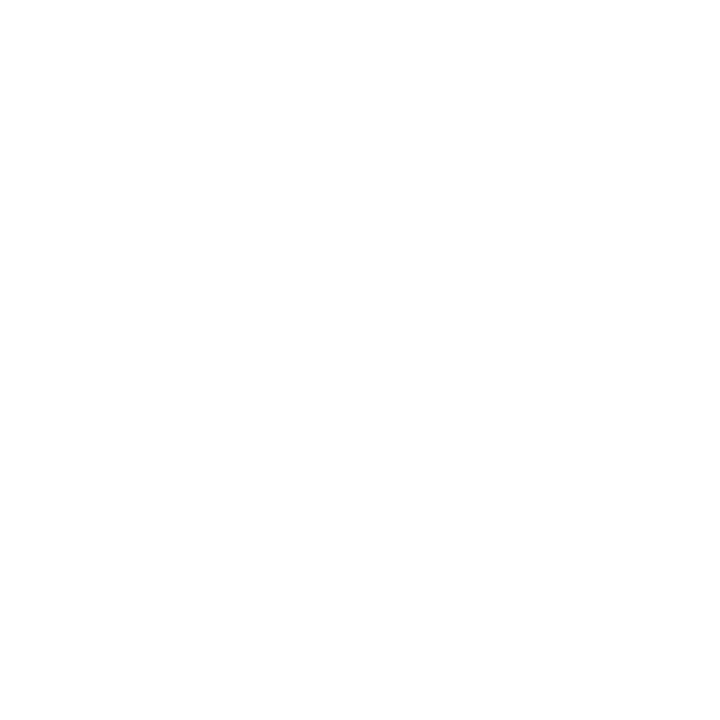

In [6]:
%matplotlib notebook
volume_BigGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### b) Small gap detection panels

<IPython.core.display.Javascript object>


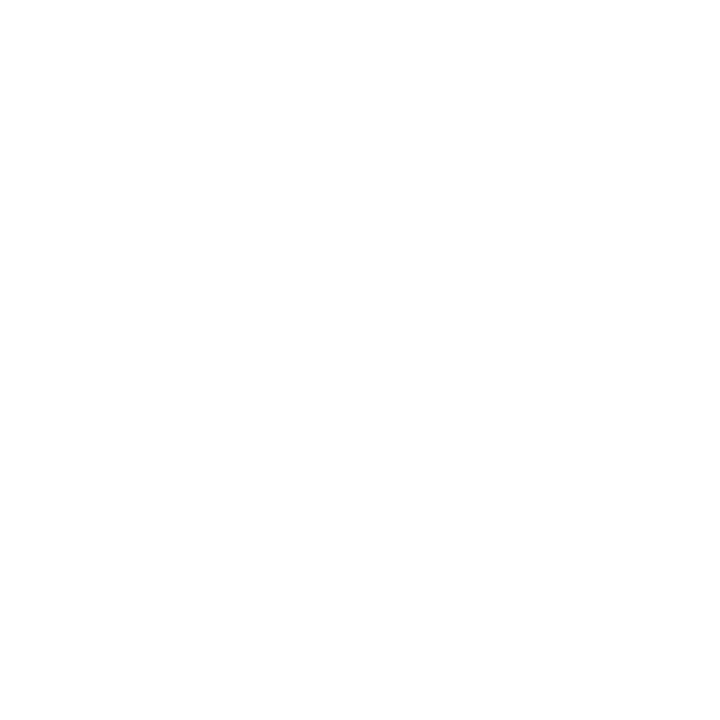

In [7]:
%matplotlib notebook
volume_SmallGap.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

#### c) Not centred detection panels

<IPython.core.display.Javascript object>


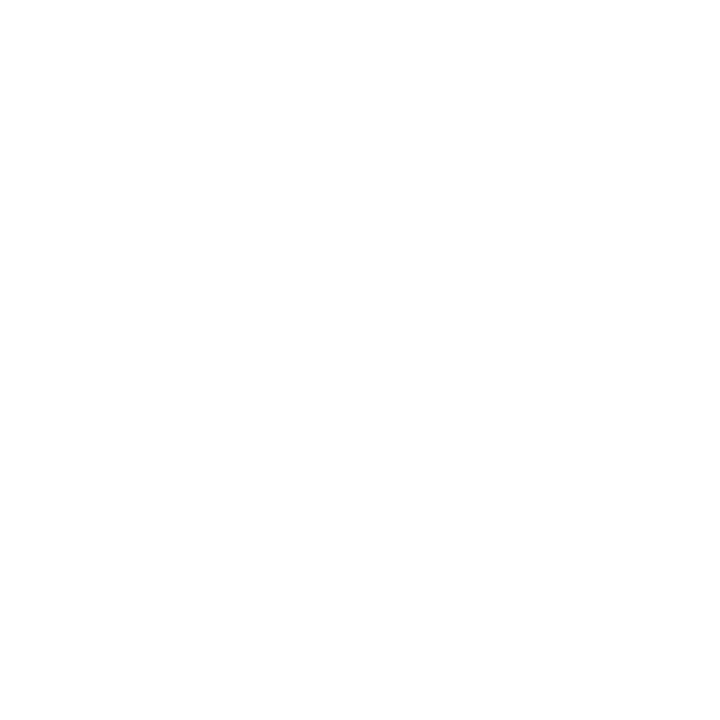

In [8]:
%matplotlib notebook
volume_NotCentred.draw(xlim=(-0.5,1.5), ylim=(-0.5,1.5), zlim=(-0.5,1.5))

In [9]:
%matplotlib inline

## **Choose scenario and define number of simulations and muon flux**

We'll continue defining the **number of simulations** we want to produce, their individual **data taking time**, and the considered **flux of muons**.

In [10]:
Simulations = 80 # number of simulations
Simulations = 800 # number of simulations
Time = 0.1 # muography measurement time of a single simulation [min]
Flux = 6845 # considered flux of muons [muons/(min*m^2)]

# TO DO: Use generic random scenarions

# Choose scenario
Scenario = "BigGapHighRes"
# Scenario = "BigGap"
# Scenario = "SmallGap"
# Scenario = "NotCentred"

## **Generate training and validation passive volumes**

Now we'll need to define how to **generate** training and validation **passive volumes**. 

Random X0 voxel volumes.

In [11]:
import torch
from torch import Tensor

In [12]:
from tomopt.volume import DetectorPanel

In [13]:
panel = DetectorPanel(res=1e3, eff=0.5, init_xyz=[0.5,0.5,0.9], init_xy_span=[0.5,0.5], m2_cost=1)
panel

<class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9000]), and xy span tensor([0.5000, 0.5000]) with budget scale tensor([1.])

In [14]:
from tomopt.volume import PanelDetectorLayer

In [15]:
dl = PanelDetectorLayer(pos='above', lw=Tensor([1,1]), z=1, size=2*0.1,
                        panels=[DetectorPanel(res=1e3, eff=0.5,
                                              init_xyz=[0.5,0.5,1-(i*(2*0.1)/4)],
                                              init_xy_span=[1.0,1.0]) for i in range(4)])
dl

PanelDetectorLayer(
  (panels): ModuleList(
    (0): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (1): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (2): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.9000]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
    (3): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([0.8500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
  )
)

In [16]:
def arb_rad_length(*,z:float, lw:Tensor, size:float) -> Tensor:
    #rad_length = torch.ones(list((lw/size).long()))
    rad_length = torch.pow(1/(torch.rand(list((lw/size).long()))*10), 2)
    return rad_length

In [17]:
from tomopt.volume import PassiveLayer

In [18]:
pl = PassiveLayer(rad_length_func=arb_rad_length, lw=Tensor([1,1]), z=0.2, size=0.1)

In [19]:
# Random generator

import numpy as np
from torch import nn

def get_layers():
    layers = []
    lwh = Tensor([1,1,1])
    size = 0.1
    init_eff = 0.5
    init_res = 1000
    n_panels = 3
    
    # Upstream detector
    z = 1.8
    layers.append(PanelDetectorLayer(pos='above', lw=lwh[:2], z=z, size=3*size,
                                     panels=[DetectorPanel(res=init_res, eff=init_eff,
                                                      init_xyz=[0.5,0.5,(z-(i)*(size/(n_panels-1)))], 
                                                           init_xy_span=[1.0,1.0]) for i in range(n_panels)]))
    
    # Passive layers
    #for z in [0.8,0.7,0.6,0.5,0.4,0.3]:
    for z in np.linspace(1.4, 0.5, 10):
        layers.append(PassiveLayer(rad_length_func=arb_rad_length, lw=lwh[:2], z=z, size=size))
    
    # Downstream detector
    z = 0.3
    layers.append(PanelDetectorLayer(pos='below', lw=lwh[:2], z=z, size=3*size,
                                     panels=[DetectorPanel(res=init_res, eff=init_eff,
                                                      init_xyz=[0.5,0.5,(z-(i)*(size/(n_panels-1)))], 
                                                           init_xy_span=[1.0,1.0]) for i in range(n_panels)]))

    return nn.ModuleList(layers) 

#get_layers()

In [20]:
from tomopt.volume import Volume

In [21]:
volume = Volume(get_layers())
volume

#volume.get_detectors()
#volume.get_passives()

Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
        (1): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.7500]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
        (2): <class 'tomopt.volume.panel.DetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.7000]), and xy span tensor([1., 1.]) with budget scale tensor([1.])
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLayer located at z=tensor([0.8000])
    (8

In [22]:
x0 = volume.get_rad_cube()
x0.shape, x0

(torch.Size([10, 10, 10]),
 tensor([[[2.1226e-02, 2.0955e-02, 1.4812e-01, 6.8266e-02, 4.1980e+00,
           1.6805e-01, 5.6984e-02, 2.7516e-02, 1.4648e-01, 1.9837e-01],
          [3.9207e-01, 1.7278e-01, 9.8086e-02, 1.7009e-02, 1.9397e+02,
           4.6466e-02, 1.1922e+00, 1.0107e-02, 1.0658e-02, 2.7826e-02],
          [2.8003e-02, 2.1175e+00, 1.3617e-01, 2.4854e-02, 1.0290e-01,
           1.0412e-01, 1.5648e+01, 2.3501e-02, 1.9739e-02, 1.9676e+00],
          [1.8259e-02, 1.2134e-02, 1.3602e-02, 1.0013e-02, 4.8849e-02,
           4.4964e+00, 3.7711e-02, 4.6060e-02, 4.8350e-01, 4.5115e-01],
          [1.0341e-02, 2.3667e-02, 1.5663e-01, 1.0260e-02, 4.8958e-02,
           1.5371e-02, 3.5166e-02, 1.7102e-01, 3.5401e+00, 2.8747e-02],
          [7.7365e-02, 1.5350e-02, 8.3865e-02, 3.3928e-02, 4.7209e-01,
           1.2301e-01, 1.3570e-02, 2.7632e-02, 6.6830e-02, 3.1585e-02],
          [2.9282e-02, 1.4870e-02, 1.2260e-02, 6.4802e-02, 4.6274e-02,
           1.1962e-01, 1.6873e-02, 1.1232e-0

In [23]:
from tomopt.plotting import plot_pred_true_x0
from tomopt.utils import x0targs_to_classtargs
from tomopt.core import X0

import numpy as np

true


<IPython.core.display.Javascript object>


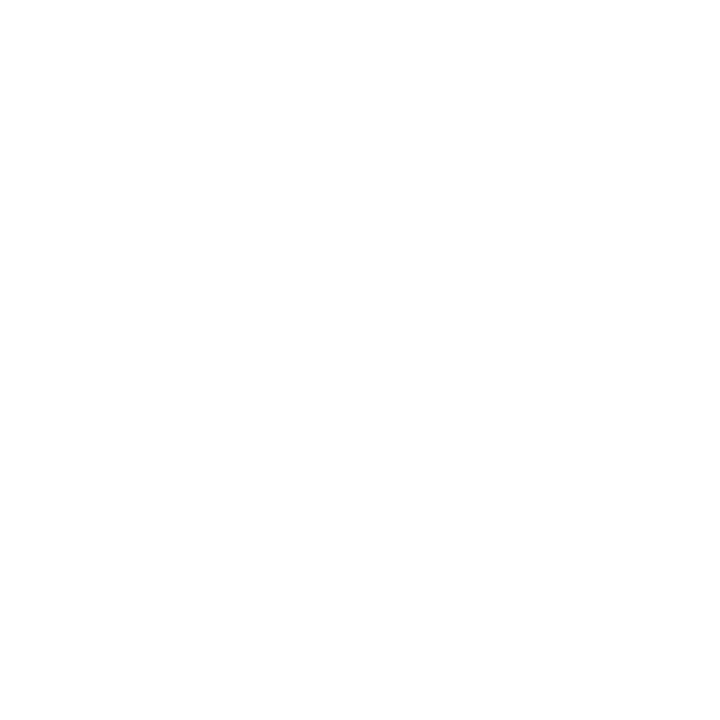

<IPython.core.display.Javascript object>


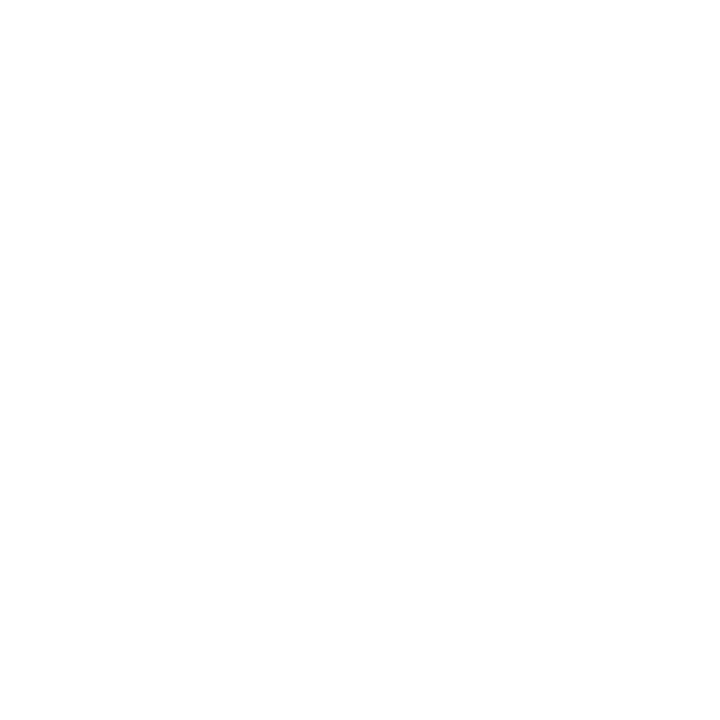

<IPython.core.display.Javascript object>


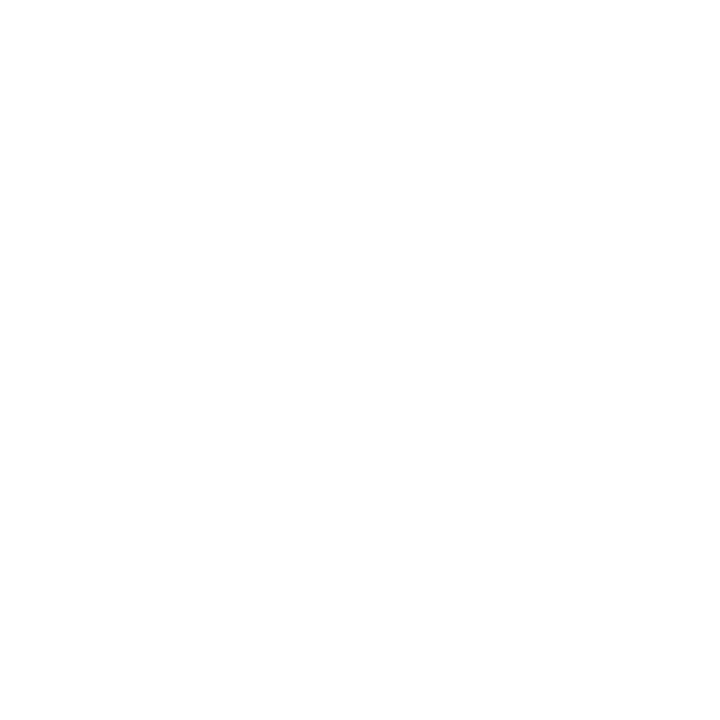

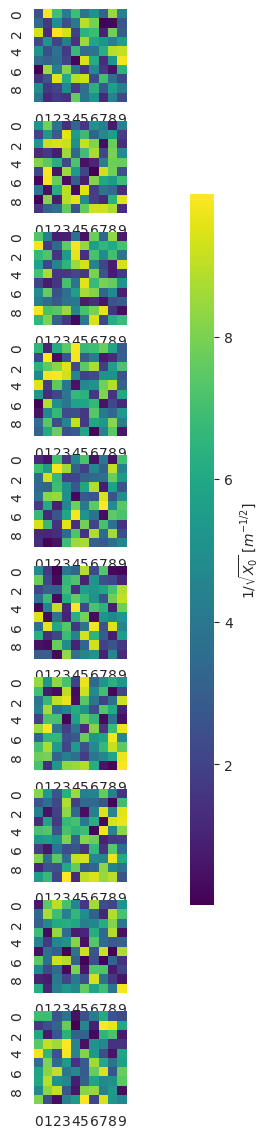

In [24]:
%matplotlib inline
# plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


In [25]:
from tomopt.optimisation import PassiveYielder


In [26]:
trn_passives = PassiveYielder([arb_rad_length]*Simulations)

trn_passives

#for p in trn_passives: print(p)

#trn_passives.passives

In [27]:
len(trn_passives)

800

In [28]:
trn_passives.passives[0]

<function __main__.arb_rad_length(*, z: float, lw: torch.Tensor, size: float) -> torch.Tensor>

true


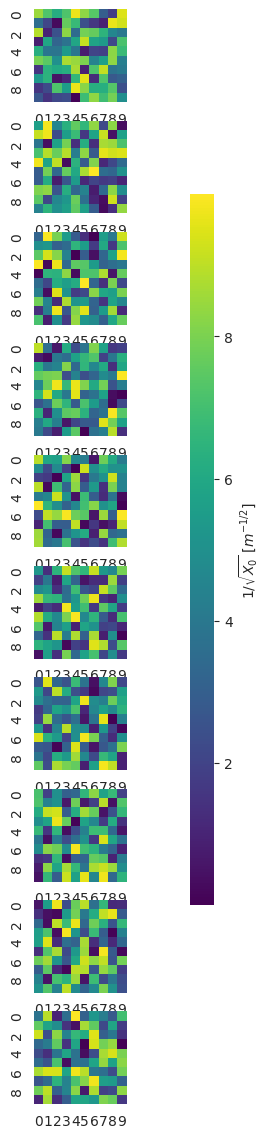

true


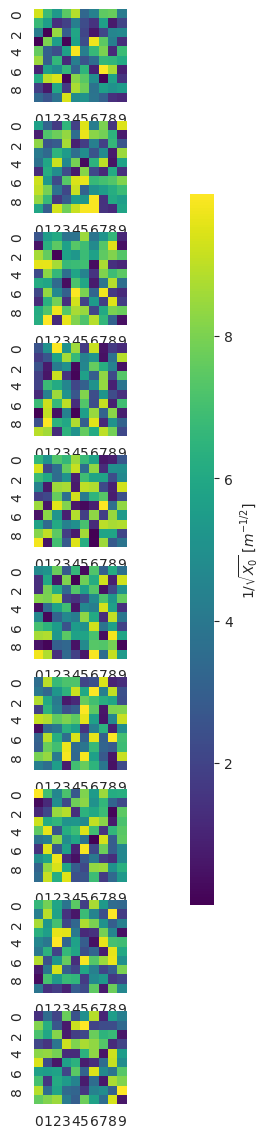

true


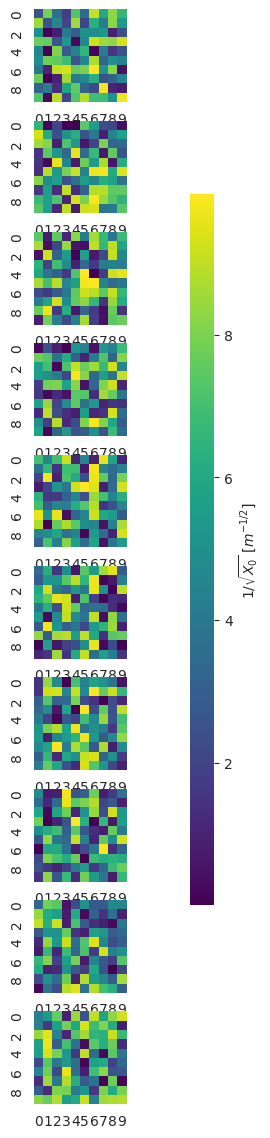

In [29]:
%matplotlib inline
for i in range(3):
    #SelectedVolume = 0
    volume.load_rad_length(trn_passives.passives[i])

    # plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
    plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


## **Generate test passive volumes**

Now we'll need to define how to **generate** example **passive volumes**. The furnace ladle is made of several elements:

 - **Ladle**: a $1\times1\times1 \:[\text{m}^3]$ bucket made of solid steel.

 - **Liquid steel**: The ladle is filled with a **random amount** of liquid steel.

 - **Slag**: Above the liquid steel is a **layer** of **slag**, with a lower density that liquid steel.

 - **Air**: The rest of the ladle is filled with air.


`LadleFurnacePassiveGenerator` class will create layouts based on varying fill-heights of a furnace ladle, with varying levels of slag.

In [30]:
from tomopt.benchmarks.ladle_furnace import LadleFurnacePassiveGenerator

In [31]:
if Scenario=="BigGapHighRes":
    volume=volume_BigGapHighRes
if Scenario=="BigGap":
    volume=volume_BigGap
if Scenario=="SmallGap":
    volume=volume_SmallGap
if Scenario=="NotCentred":
    volume=volume_NotCentred


print(volume)
# volume.get_detectors(), volume.get_passives()

passive_gen = LadleFurnacePassiveGenerator(volume)

Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

We'll generate 10 volumes at a every fill-height. The 10cm of slag will be present for ever volume.

In [32]:
HEIGHTS = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
N_PASSIVES_PER_H = int(Simulations/len(HEIGHTS))

test_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)
                               for _ in range(N_PASSIVES_PER_H) for h in HEIGHTS])

## Just one
#h = 1.3
#trn_passives = PassiveYielder([passive_gen._generate(fixed_mat_z=h, fixed_slag_z=h+0.1)])

This is the amount of passive volumes generated.

In [33]:
len(HEIGHTS), N_PASSIVES_PER_H, len(test_passives)

(8, 100, 800)

Let's visualise one of these volume layouts by repurposing one of the visualisers in TomOpt

In [34]:
test_passives

In [35]:
SelectedVolume = 10
test_passives.passives[SelectedVolume]

(<function tomopt.benchmarks.ladle_furnace.data.LadleFurnacePassiveGenerator._generate.<locals>.generator(*, z: torch.Tensor, lw: torch.Tensor, size: float) -> torch.Tensor>,
 tensor([0.8000]))

In [36]:
SelectedVolume = 10
f,t = test_passives.passives[SelectedVolume]
volume.load_rad_length(f, t)

In [37]:
f

<function tomopt.benchmarks.ladle_furnace.data.LadleFurnacePassiveGenerator._generate.<locals>.generator(*, z: torch.Tensor, lw: torch.Tensor, size: float) -> torch.Tensor>

In [38]:
t

tensor([0.8000])

In [39]:
# Get X0 of all voxels
x0 = volume.get_rad_cube()
x0.shape, x0

(torch.Size([10, 10, 10]),
 tensor([[[1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02],
          [1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02, 1.7820e-02,
           1.7820e-02, 1.7820e-02, 1.7820e-0

In [40]:
type(1/np.sqrt(volume.get_rad_cube()))

torch.Tensor

In [41]:
volume.get_rad_cube()[:,4,4]*100

tensor([1.7820e+00, 1.9910e+00, 1.9910e+00, 1.9910e+00, 8.2110e+00, 3.0390e+04,
        3.0390e+04, 3.0390e+04, 3.0390e+04, 3.0390e+04])

true


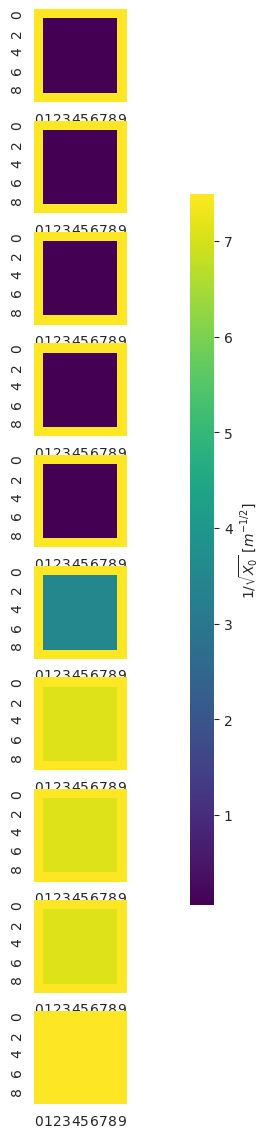

In [42]:
%matplotlib inline
# plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


In the plot of the cell above the layers of the ladle can be observed, coloured depending on the X0 of the voxel material:

 - Yellow = **ladle** (steel) 
 - Light green = **liquid steel** 
 - Dark green = **Slag** 
 - Blue = **Air**

The inverse of the square root of X0 has been plotted, a value which is approximately linear to the material density. We can see that the metals have very similar X0, but they are slightly distinguishable from the slag.

## **Muon generation and propagation**


In [58]:
from tomopt.muon import MuonGenerator2016 as MuonGenerator

In [59]:
# gen = MuonGenerator.from_volume(volume, fixed_mom=5)
gen = MuonGenerator.from_volume(volume, fixed_mom=None)
gen

Muon generator: x,y range: (-0.40192377427276926, 1.4019237742727693), (-0.40192377427276926, 1.4019237742727693). Energy sampled from 0.5087855416698359-491.5127197474533 GeV.

In [60]:
from tomopt.muon import MuonBatch

In [61]:
muons = MuonBatch(gen(2000), init_z=1.8)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(-0.3112), muons.y[0]=tensor(1.2092), muons.z[0]=tensor(1.8000), muons.theta[0]=tensor(0.1436)'

In [62]:
volume(mu=muons)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

'muons.x[0]=tensor(-0.0895), muons.y[0]=tensor(1.0731), muons.z[0]=tensor(0.), muons.theta[0]=tensor(0.1436)'

In [63]:
hits = muons.get_hits()
hits

{'above': {'reco_xyz': tensor([[[-3.3811e+05,  2.6003e+03,  1.8000e+00],
           [ 1.4813e+07, -9.2620e+06,  1.6500e+00],
           [ 2.8902e+04,  8.6516e+04,  1.5000e+00]],
  
          [[ 1.0216e+05,  1.1970e+05,  1.8000e+00],
           [ 1.0539e+05, -1.5050e+05,  1.6500e+00],
           [ 1.0102e+05, -1.1165e+04,  1.5000e+00]],
  
          [[ 1.3078e+04,  4.6110e+04,  1.8000e+00],
           [-2.1397e+07, -1.2827e+09,  1.6500e+00],
           [-1.3009e+05,  4.0811e+05,  1.5000e+00]],
  
          ...,
  
          [[ 1.4827e+05,  1.9185e+03,  1.8000e+00],
           [ 1.5419e+05,  1.2460e+07,  1.6500e+00],
           [-1.0381e+05, -2.7721e+05,  1.5000e+00]],
  
          [[-6.5787e+04,  2.1855e+04,  1.8000e+00],
           [-8.1869e+04, -2.8296e+04,  1.6500e+00],
           [-1.6451e+05,  2.6800e+05,  1.5000e+00]],
  
          [[ 1.0177e+05, -6.5975e+04,  1.8000e+00],
           [-3.3773e+05, -6.2354e+04,  1.6500e+00],
           [-2.1409e+05, -5.7402e+04,  1.5000e+00]]], gra

In [64]:
hits['above']['reco_xyz'].shape  # [muons, detector layer, xyz]

torch.Size([2000, 3, 3])

In [65]:
hits['above']['reco_xyz'][:, 0, 0] # [all muons, 1st layer from the top, x]
hits['above']['reco_xyz'][:, 0, 1] # [all muons, 1st layer from the top, y]

tensor([  2600.3286, 119699.8828,  46109.5742,  ...,   1918.5170,
         21854.7480, -65974.5078], grad_fn=<SelectBackward0>)

In [66]:
import matplotlib.pyplot as plt

(array([  3.,  23., 109., 500., 815., 421., 111.,  13.,   4.,   1.]),
 array([-670116.5     , -519057.75    , -367998.96875 , -216940.21875 ,
         -65881.453125,   85177.3125  ,  236236.078125,  387294.84375 ,
         538353.625   ,  689412.375   ,  840471.125   ]),
 <BarContainer object of 10 artists>)

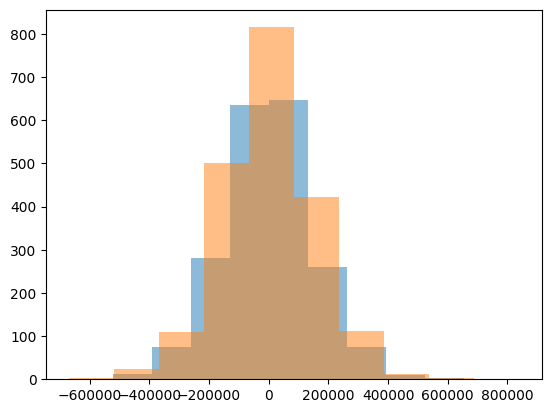

In [67]:
plt.hist(hits['above']['reco_xyz'][:, 0, 0].detach().numpy(), alpha=0.5)
plt.hist(hits['above']['reco_xyz'][:, 0, 1].detach().numpy(), alpha=0.5)

In [68]:
from tomopt.inference import ScatterBatch

In [69]:
muons.mom.shape

torch.Size([2000])

In [72]:
volume

Volume(
  (layers): ModuleList(
    (0): PanelDetectorLayer(
      (panels): ModuleList(
        (0): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.8000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (1): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.6500]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
        (2): <class 'tomopt.volume.panel.SigmoidDetectorPanel'> located at xy=tensor([0.5000, 0.5000]), z=tensor([1.5000]), and xy span tensor([1., 1.]) with budget scale 1.4285714626312256
      )
    )
    (1): PassiveLayer located at z=tensor([1.4000])
    (2): PassiveLayer located at z=tensor([1.3000])
    (3): PassiveLayer located at z=tensor([1.2000])
    (4): PassiveLayer located at z=tensor([1.1000])
    (5): PassiveLayer located at z=tensor([1.])
    (6): PassiveLayer located at z=tensor([0.9000])
    (7): PassiveLay

true


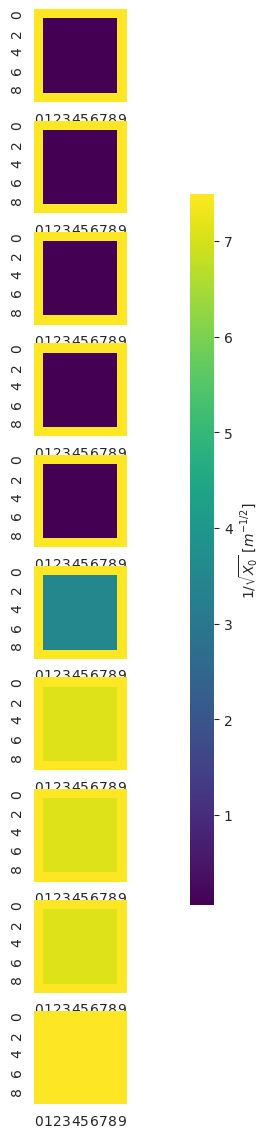

In [73]:
%matplotlib inline
# plot_pred_true_x0(pred=1/np.sqrt(volume.get_rad_cube()), true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X0} \ [cm^{-1/2}]$')
plot_pred_true_x0(true=1/np.sqrt(volume.get_rad_cube()), ColorBarLabel=r'$1/\sqrt{X_0} \ [m^{-1/2}]$')


In [70]:
%%time
sb = ScatterBatch(mu=muons, volume=volume)

CPU times: user 23.1 ms, sys: 4 µs, total: 23.1 ms
Wall time: 12.5 ms


In [71]:
muons.mom.shape

torch.Size([0])

In [55]:
# Efficiency of every muon in each detector panel
sb.hit_effs.shape

torch.Size([0, 6, 1])

In [56]:
muons.mom.shape

torch.Size([0])

In [57]:
len(sb.hit_effs[0, :, 0])
sb.hit_effs.flatten().shape

IndexError: index 0 is out of bounds for dimension 0 with size 0

In [ ]:
E = sb.hit_effs[:, 0, 0]
for i in range(1, len(sb.hit_effs[0, :, 0])):
    E = E + sb.hit_effs[:, i, 0]
    
E = E/len(sb.hit_effs[0, :, 0])
E = E.detach().numpy()

In [ ]:
plt.hist(sb.hit_effs.flatten().detach().numpy(), alpha=0.5, density=True, bins=np.linspace(0,1,20))
#plt.show()

# Average efficiency of every muon in all the detector panels
plt.hist(E, alpha=0.5, density=True, bins=np.linspace(0,1,20))

plt.xlim([0, 1])
plt.show()

In [ ]:
plt.hist(sb.above_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()
plt.hist(sb.below_gen_hits[:, 0, 0].detach().numpy(), alpha=0.5)
plt.show()

sb.above_gen_hits.shape, sb.below_gen_hits.shape

In [ ]:
%%time
sb.poca_xyz, sb.poca_xyz_unc

In [ ]:
sb.plot_scatter(idx=0)

# Test data: run multiple simulations and get estimator (NN) inputs (per muon basis hits) and inference objective (voxel-wise X0)

### Generation

In [ ]:
GeneratedMuons = 10000
muons = MuonBatch(gen(10000), init_z=1.8)
f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

In [ ]:
plt.hist(muons.x)
plt.show()

plt.hist(muons.y)
plt.show()

min(muons.x)

In [ ]:
from tomopt.tools import prog_bar

#TrueSteelLevels = np.zeros(len(trn_passives.passives))
#TrueSteelLevels[:] = np.nan

#Poca_z_means = np.zeros(len(trn_passives.passives))
#Poca_z_means[:] = np.nan

# Muons per volume
GeneratedMuons = 10

print("Generating " + str(len(trn_passives.passives)) + " simulations")

for i in range(0, len(trn_passives.passives)):
    
    #pint(i)
    
    prog_bar(percent=100.0*(i+1)/len(trn_passives.passives))
    
    SelectedVolume = i
    f,t = trn_passives.passives[SelectedVolume]
    volume.load_rad_length(f, t)
    
    # plot_pred_true_x0(1/np.sqrt(volume.get_rad_cube()), 1/np.sqrt(volume.get_rad_cube()))
    
    # Generate
    muons = MuonBatch(gen(GeneratedMuons), init_z=1.8)
    f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'

    # Propagate
    volume(mu=muons)
    f'{muons.x[0]=}, {muons.y[0]=}, {muons.z[0]=}, {muons.theta[0]=}'
    
    #print(muons.mom.shape)

    # Inputs
    X_tensor_OneSim = torch.cat((muons.get_hits()['above']['reco_xyz'][:, 0, 0:2],  # [detector above] [all muons, 1st layer from the top, x-y-z]
                          muons.get_hits()['above']['reco_xyz'][:, 2, 0:2], # [detector above] [all muons, 3rd layer from the top, x-y]
                          muons.get_hits()['below']['reco_xyz'][:, 0, 0:2], # [detector below] [all muons, 1st layer from the top, x-y]
                          muons.get_hits()['below']['reco_xyz'][:, 2, 0:2], # [detector below] [all muons, 3rd layer from the top, x-y]
                         ), 1)
    
    X_tensor_OneSim = torch.cat([X_tensor_OneSim, muons.mom.unsqueeze(0).transpose(0, 1)], dim=1)
    
    if i==0:
        X_tensor = X_tensor_OneSim
    else:
        X_tensor = torch.cat((X_tensor, X_tensor_OneSim), 0)
    
    
    # Outputs
    #x0 = volume.get_rad_cube()
    x0 = 1/np.sqrt(volume.get_rad_cube())
    y_tensor_OneSim = x0.flatten()
    
    #for j in range(0, X_tensor_OneSim.shape[0]):
    #    y_tensor_OneSim = torch.cat((y_tensor_OneSim.unsqueeze(0).transpose(0, 1), y_tensor_OneSim.unsqueeze(0).transpose(0, 1)), 1)

    y_tensor_OneSim = y_tensor_OneSim.repeat(X_tensor_OneSim.shape[0], 1)

    if i==0:
        #y_tensor = y_tensor_OneSim.unsqueeze(0).transpose(0, 1)
        y_tensor = y_tensor_OneSim
    else:
        #y_tensor = torch.cat((y_tensor, y_tensor_OneSim.unsqueeze(0).transpose(0, 1)), 1)
        y_tensor = torch.cat((y_tensor, y_tensor_OneSim), 0)
    
    #sb = ScatterBatch(mu=muons, volume=volume)
    #sb.poca_xyz, sb.poca_xyz_unc
    


In [ ]:
X_tensor.shape

In [ ]:
y_tensor.shape

In [ ]:
len(trn_passives.passives)*GeneratedMuons

In [ ]:
X_tensor[0,:]

In [ ]:
# Momentum
plt.hist(X_tensor[:,8].detach().numpy())

In [ ]:
# 1/sqrt(x0)
plt.hist(y_tensor.detach().numpy().flatten())

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# To save history evolution
train_losses = []
val_losses = []

# Make sure input tensors are marked as constants:
X_tensor = X_tensor.detach()
y_tensor = y_tensor.detach()

# Set random seed for reproducibility
torch.manual_seed(42)

## Simulated dataset: 500 samples, 13 inputs → 1000 outputs
#X_tensor = torch.randn(500, 13)
#y_tensor = torch.randn(500, 1000)

# Optional: Normalize data (standardization)
X_mean, X_std = X_tensor.mean(0, keepdim=True), X_tensor.std(0, keepdim=True)
y_mean, y_std = y_tensor.mean(0, keepdim=True), y_tensor.std(0, keepdim=True)

X_tensor = (X_tensor - X_mean) / (X_std + 1e-8)
y_tensor = (y_tensor - y_mean) / (y_std + 1e-8)

# Train/test split using torch
n_samples = X_tensor.size(0)
perm = torch.randperm(n_samples)
split_idx = int(0.8 * n_samples)
train_idx, test_idx = perm[:split_idx], perm[split_idx:]

X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_test, y_test = X_tensor[test_idx], y_tensor[test_idx]

# Define the model
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1000)
        )

    def forward(self, x):
        return self.net(x)

model = RegressionNN()

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
EPOCHS = 20
EACH = EPOCHS/10
for epoch in range(EPOCHS):
    model.train()
    preds = model(X_train)
    loss = criterion(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % EACH == 0:
    #if (epoch + 1) % 10 == 0:

        train_losses.append(loss.item())  # 📌 Save training loss

        # Validation    
        model.eval()
        with torch.no_grad():
            val_preds = model(X_test)
            val_loss = criterion(val_preds, y_test)
        
        val_losses.append(val_loss.item())  # 📌 Save validation loss
        print(f"Epoch {epoch+1:>2}: Train Loss = {loss.item():.4f} | Val Loss = {val_loss.item():.4f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
y_test.flatten().shape

In [ ]:
voxel_index = 600  # Can change to any voxel index [0, 999]

predicted_values = val_preds[:, voxel_index].cpu().numpy()
true_values = y_test[:, voxel_index].cpu().numpy()

In [ ]:
true_values

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
#plt.hist(predicted_values, bins=30, alpha=0.6, label='Predicted', color='orange')
plt.hist(true_values, bins=30, alpha=0.6, label='True', color='blue')
#plt.hist(y_test.flatten(), bins=21, alpha=0.6, label='True', color='blue')
plt.title(f'Voxel #{voxel_index} - Value Distribution')
plt.xlabel('Normalized Density')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()
